# [Final project](https://www.edu.goit.global/learn/25315460/26519706/26524804/training?blockId=28528871)
- Kaggle competition: [Deep Learning for Computer Vision and NLP 2025-05](https://www.kaggle.com/competitions/deep-learning-for-computer-vision-and-nlp-2025-05/leaderboard)
- Dataset: [PetFinder.my Adoption Prediction](https://www.kaggle.com/competitions/petfinder-adoption-prediction/data)

In [1]:
# import re
# import gc
# import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
# import orjson as json
# from concurrent.futures import ThreadPoolExecutor
# from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import torch
from transformers import AutoTokenizer, AutoModel, CLIPProcessor, CLIPModel
import nltk

nltk.download("stopwords")
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words("english"))

import optuna

2025-05-27 12:49:21.280511: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-27 12:49:21.287375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748339361.295438  182013 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748339361.297941  182013 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748339361.303996  182013 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Configs

In [5]:
DATA = Path("~/Projects/DataSets/GoIT/petfinder-final").expanduser()
TRAIN_CSV = DATA / "train.csv"
TEST_CSV = DATA / "test.csv"
IMG_TRAIN_DIR = DATA / "images/train"
IMG_TEST_DIR = DATA / "images/test"
OUTPUTS = DATA / "outputs"
OUTPUTS.mkdir(exist_ok=True)

## Utils: QWK & Plots

In [6]:
# https://github.com/benhamner/Metrics
# https://www.kaggle.com/competitions/petfinder-adoption-prediction/discussion/76106


def confusion_matrix(rater_a, rater_b, min_rating=None, max_rating=None):
    """Returns the confusion matrix between rater's ratings."""
    assert len(rater_a) == len(rater_b)
    if min_rating is None:
        min_rating = min(rater_a + rater_b)
    if max_rating is None:
        max_rating = max(rater_a + rater_b)
    num_ratings = int(max_rating - min_rating + 1)
    conf_mat = [[0 for i in range(num_ratings)] for j in range(num_ratings)]
    for a, b in zip(rater_a, rater_b):
        conf_mat[a - min_rating][b - min_rating] += 1
    return conf_mat


def histogram(ratings, min_rating=None, max_rating=None):
    """Returns the counts of each type of rating that a rater made."""
    if min_rating is None:
        min_rating = min(ratings)
    if max_rating is None:
        max_rating = max(ratings)
    num_ratings = int(max_rating - min_rating + 1)
    hist_ratings = [0 for x in range(num_ratings)]
    for r in ratings:
        hist_ratings[r - min_rating] += 1
    return hist_ratings


def quadratic_weighted_kappa(y, y_pred):
    """
    Calculates the quadratic weighted kappa
    axquadratic_weighted_kappa calculates the quadratic weighted kappa
    value, which is a measure of inter-rater agreement between two raters
    that provide discrete numeric ratings.  Potential values range from -1
    (representing complete disagreement) to 1 (representing complete
    agreement).  A kappa value of 0 is expected if all agreement is due to
    chance.
    quadratic_weighted_kappa(rater_a, rater_b), where rater_a and rater_b
    each correspond to a list of integer ratings.  These lists must have the
    same length.
    The ratings should be integers, and it is assumed that they contain
    the complete range of possible ratings.
    quadratic_weighted_kappa(X, min_rating, max_rating), where min_rating
    is the minimum possible rating, and max_rating is the maximum possible
    rating
    """
    rater_a = y
    rater_b = y_pred
    min_rating = None
    max_rating = None
    rater_a = np.array(rater_a, dtype=int)
    rater_b = np.array(rater_b, dtype=int)
    assert len(rater_a) == len(rater_b)
    if min_rating is None:
        min_rating = min(min(rater_a), min(rater_b))
    if max_rating is None:
        max_rating = max(max(rater_a), max(rater_b))
    conf_mat = confusion_matrix(rater_a, rater_b, min_rating, max_rating)
    num_ratings = len(conf_mat)
    num_scored_items = float(len(rater_a))

    hist_rater_a = histogram(rater_a, min_rating, max_rating)
    hist_rater_b = histogram(rater_b, min_rating, max_rating)

    numerator = 0.0
    denominator = 0.0

    for i in range(num_ratings):
        for j in range(num_ratings):
            expected_count = hist_rater_a[i] * hist_rater_b[j] / num_scored_items
            d = pow(i - j, 2.0) / pow(num_ratings - 1, 2.0)
            numerator += d * conf_mat[i][j] / num_scored_items
            denominator += d * expected_count / num_scored_items

    return 1.0 - numerator / denominator


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", figsize=(8, 6)):
    """Plot a confusion matrix using seaborn heatmap."""
    min_rating = min(min(y_true), min(y_pred))
    max_rating = max(max(y_true), max(y_pred))

    conf_mat = confusion_matrix(y_true, y_pred, min_rating, max_rating)
    conf_mat = np.array(conf_mat)

    labels = [str(i + min_rating) for i in range(len(conf_mat))]

    plt.figure(figsize=figsize)
    sns.heatmap(
        conf_mat,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Count"},
    )

    plt.title(title, fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted AdoptionSpeed", fontsize=12, fontweight="bold")
    plt.ylabel("True AdoptionSpeed", fontsize=12, fontweight="bold")

    # Add QWK score to the plot
    qwk = quadratic_weighted_kappa(y_true, y_pred)
    plt.text(
        0.02,
        0.98,
        f"QWK: {qwk:.4f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.8),
        verticalalignment="top",
    )

    plt.tight_layout()
    plt.show()

    return conf_mat


def plot_detailed_results(y_true, y_pred, title="Results"):
    """Plot comprehensive visual evaluation results including confusion matrix and distributions."""
    qwk = quadratic_weighted_kappa(y_true, y_pred)

    min_rating = min(min(y_true), min(y_pred))
    max_rating = max(max(y_true), max(y_pred))

    conf_mat = confusion_matrix(y_true, y_pred, min_rating, max_rating)
    hist_true = histogram(y_true, min_rating, max_rating)
    hist_pred = histogram(y_pred, min_rating, max_rating)

    fig = plt.figure(figsize=(16, 12))

    # Confusion Matrix
    plt.subplot(2, 3, 1)
    conf_mat_np = np.array(conf_mat)
    labels = [str(i + min_rating) for i in range(len(conf_mat))]
    sns.heatmap(
        conf_mat_np,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Count"},
    )
    plt.title(f"Confusion Matrix\nQWK: {qwk:.4f}", fontsize=12, fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")

    # Class Distribution Comparison
    plt.subplot(2, 3, 2)
    x_pos = np.arange(len(hist_true))
    width = 0.35
    plt.bar(
        x_pos - width / 2, hist_true, width, label="True", alpha=0.8, color="skyblue"
    )
    plt.bar(
        x_pos + width / 2,
        hist_pred,
        width,
        label="Predicted",
        alpha=0.8,
        color="orange",
    )
    plt.xlabel("AdoptionSpeed Class", fontweight="bold")
    plt.ylabel("Count", fontweight="bold")
    plt.title("Class Distribution Comparison", fontsize=12, fontweight="bold")
    plt.xticks(x_pos, [str(i + min_rating) for i in range(len(hist_true))])
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    # Normalized Confusion Matrix
    plt.subplot(2, 3, 3)
    conf_mat_norm = conf_mat_np.astype("float") / conf_mat_np.sum(axis=1)[:, np.newaxis]
    sns.heatmap(
        conf_mat_norm,
        annot=True,
        fmt=".2f",
        cmap="Reds",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Proportion"},
    )
    plt.title("Normalized Confusion Matrix\n(Row-wise)", fontsize=12, fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")

    # Error Analysis
    plt.subplot(2, 3, 4)
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    errors = y_pred_arr - y_true_arr

    error_counts = np.bincount(errors + max_rating, minlength=2 * max_rating + 1)
    error_labels = list(range(-max_rating, max_rating + 1))

    colors = ["red" if x < 0 else "green" if x > 0 else "gray" for x in error_labels]
    plt.bar(error_labels, error_counts, color=colors, alpha=0.7)
    plt.xlabel("Prediction Error (Pred - True)", fontweight="bold")
    plt.ylabel("Count", fontweight="bold")
    plt.title("Prediction Error Distribution", fontsize=12, fontweight="bold")
    plt.axvline(x=0, color="black", linestyle="--", alpha=0.8)
    plt.grid(axis="y", alpha=0.3)

    # Accuracy by Class
    plt.subplot(2, 3, 5)
    class_accuracies = []
    for i in range(len(conf_mat)):
        if sum(conf_mat[i]) > 0:
            accuracy = conf_mat[i][i] / sum(conf_mat[i])
            class_accuracies.append(accuracy)
        else:
            class_accuracies.append(0)

    class_names = [str(i + min_rating) for i in range(len(class_accuracies))]
    colors = plt.cm.RdYlGn([acc for acc in class_accuracies])
    bars = plt.bar(class_names, class_accuracies, color=colors, alpha=0.8)
    plt.xlabel("AdoptionSpeed Class", fontweight="bold")
    plt.ylabel("Accuracy", fontweight="bold")
    plt.title("Per-Class Accuracy", fontsize=12, fontweight="bold")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)

    # Add value labels
    for bar, acc in zip(bars, class_accuracies):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{acc:.2f}",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    # Prediction Scatter Plot
    plt.subplot(2, 3, 6)
    plt.scatter(y_true, y_pred, alpha=0.6, s=30)
    plt.plot(
        [min_rating, max_rating],
        [min_rating, max_rating],
        "r--",
        alpha=0.8,
        linewidth=2,
    )
    plt.xlabel("True AdoptionSpeed", fontweight="bold")
    plt.ylabel("Predicted AdoptionSpeed", fontweight="bold")
    plt.title("True vs Predicted Scatter", fontsize=12, fontweight="bold")
    plt.grid(True, alpha=0.3)

    # Add correlation coefficient
    correlation = np.corrcoef(y_true, y_pred)[0, 1]
    plt.text(
        0.05,
        0.95,
        f"Correlation: {correlation:.3f}",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
        verticalalignment="top",
    )

    # Title
    fig.suptitle(
        f"{title} - Comprehensive Evaluation (QWK: {qwk:.4f})",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

    return {
        "qwk": qwk,
        "confusion_matrix": conf_mat_np,
        "class_accuracies": class_accuracies,
        "correlation": correlation,
    }


def plot_test_predictions_distribution(
    predictions, title="Test Predictions Distribution"
):
    """Plot the distribution of test predictions with beautiful visualization."""
    pred_counts = np.bincount(predictions.astype(int))
    classes = np.arange(len(pred_counts))

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Bar plot
    colors = plt.cm.viridis(np.linspace(0, 1, len(pred_counts)))
    bars = ax1.bar(classes, pred_counts, color=colors, alpha=0.8, edgecolor="black")
    ax1.set_xlabel("AdoptionSpeed Class", fontweight="bold", fontsize=12)
    ax1.set_ylabel("Count", fontweight="bold", fontsize=12)
    ax1.set_title("Test Predictions Count by Class", fontweight="bold", fontsize=14)
    ax1.grid(axis="y", alpha=0.3)

    # Add value labels on bars
    for bar, count in zip(bars, pred_counts):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(pred_counts) * 0.01,
            str(count),
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    # Pie chart
    ax2.pie(
        pred_counts,
        labels=[f"Class {i}" for i in classes],
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
    )
    ax2.set_title("Test Predictions Distribution", fontweight="bold", fontsize=14)

    # Title
    fig.suptitle(
        f"{title} (Total: {len(predictions)} samples)", fontsize=16, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\n=== {title} Summary ===")
    print(f"Total samples: {len(predictions)}")
    for i, count in enumerate(pred_counts):
        percentage = (count / len(predictions)) * 100
        print(f"Class {i}: {count:>4} ({percentage:>5.1f}%)")

## EDA

### Data Cleaning, Sentiment,  Metadata

In [ ]:
# def load_metadata(pet_id, meta_dir):
#     """Load metadata for a given pet ID from the specified directory."""
#     meta_files = list(meta_dir.glob(f"{pet_id}*.json"))
#     if not meta_files:
#         return pd.Series({"meta_color_score": np.nan, "meta_crop_conf": np.nan})
#     with open(meta_files[0], "r") as f:
#         meta = pd.json_normalize(json.load(f))
#     color_score = meta.get("imagePropertiesAnnotation.dominantColors.colors", [[{}]])[
#         0
#     ][0].get("score", 0)
#     crop_conf = meta.get("cropHintsAnnotation.cropHints", [[{}]])[0][0].get(
#         "confidence", 0
#     )
#     return pd.Series({"meta_color_score": color_score, "meta_crop_conf": crop_conf})


# def load_sentiment(pet_id, senti_dir):
#     """Load sentiment analysis results for a given pet ID from the specified directory."""
#     senti_files = list(senti_dir.glob(f"{pet_id}.json"))
#     if not senti_files:
#         return pd.Series({"sentiment_magnitude": np.nan, "sentiment_score": np.nan})
#     with open(senti_files[0], "r") as f:
#         senti = json.load(f)
#     doc_sent = senti.get("documentSentiment", {})
#     magnitude = doc_sent.get("magnitude", 0)
#     score = doc_sent.get("score", 0)
#     return pd.Series({"sentiment_magnitude": magnitude, "sentiment_score": score})


# def clean_and_merge_data():
#     """Load, clean, and merge training and test data with metadata and sentiment features."""
#     train_df = pd.read_csv(TRAIN_CSV)
#     test_df = pd.read_csv(TEST_CSV)
#     for df in [train_df, test_df]:
#         df["Description"] = df["Description"].fillna("").str.lower().str.strip()
#         df["Name"] = df["Name"].fillna("no name").str.lower().str.strip()
#         df["Age"] = df["Age"].clip(0, 255)
#     for df, meta_dir, senti_dir, split in [
#         (train_df, META_TRAIN_DIR, SENTI_TRAIN_DIR, "train"),
#         (test_df, META_TEST_DIR, SENTI_TEST_DIR, "test"),
#     ]:
#         meta_features = []
#         senti_features = []
#         for pet_id in tqdm(df["PetID"], desc=f"Metadata/Sentiment ({split})"):
#             meta_feat = load_metadata(pet_id, meta_dir)
#             senti_feat = load_sentiment(pet_id, senti_dir)
#             meta_features.append(meta_feat)
#             senti_features.append(senti_feat)
#         meta_df = pd.DataFrame(meta_features)
#         senti_df = pd.DataFrame(senti_features)
#         df.reset_index(drop=True, inplace=True)
#         df[meta_df.columns] = meta_df
#         df[senti_df.columns] = senti_df
#     mask_train = (train_df["Description"] != "") & (
#         train_df["meta_color_score"].notnull()
#     )
#     mask_test = (test_df["Description"] != "") & (test_df["meta_color_score"].notnull())
#     train_df = train_df[mask_train].reset_index(drop=True)
#     test_df = test_df[mask_test].reset_index(drop=True)
#     train_df.to_pickle(OUTPUTS / "train_clean.pkl")
#     test_df.to_pickle(OUTPUTS / "test_clean.pkl")
#     return train_df, test_df


# if (
#     not (OUTPUTS / "train_clean.pkl").exists()
#     and not (OUTPUTS / "test_clean.pkl").exists()
# ):
#     train_df, test_df = clean_and_merge_data()

In [9]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
display(train_df.head())

,PetID,Description,AdoptionSpeed
0,d3b4f29f8,Mayleen and Flo are two lovely adorable sister...,2
1,e9dc82251,A total of 5 beautiful Tabbys available for ad...,2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and ...,2
3,693a90fda,Neil is a healthy and active ~2-month-old fema...,2
4,9d08c85ef,Gray kitten available for adoption in sungai p...,2


In [12]:
display(train_df.describe().T)
display(test_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
AdoptionSpeed,6431.0,2.683719,1.118951,1.0,2.0,3.0,4.0,4.0


,count,unique,top,freq
PetID,1891,1891,6697a7f62,1
Description,1890,1836,For Adoption,21


In [13]:
display(train_df.info())
display(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6431 entries, 0 to 6430
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PetID          6431 non-null   object
 1   Description    6426 non-null   object
 2   AdoptionSpeed  6431 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 150.9+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891 entries, 0 to 1890
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PetID        1891 non-null   object
 1   Description  1890 non-null   object
dtypes: object(2)
memory usage: 29.7+ KB


None

In [14]:
display(train_df.isnull().sum())
display(test_df.isnull().sum())

PetID            0
Description      5
AdoptionSpeed    0
dtype: int64

PetID          0
Description    1
dtype: int64

### Handling Empty Descriptions

In [17]:
def clean_and_save_data(fill_empty_desc=False, empty_desc_value="no description"):
    """
    Clean, and check for image file existence. 
    Saves cleaned data with image existence flags as .pkl
    """
    train_df = pd.read_csv(TRAIN_CSV)
    test_df = pd.read_csv(TEST_CSV)
    
    train_empty = train_df["Description"].isna().sum()
    test_empty = test_df["Description"].isna().sum()
    print(f"Empty descriptions before processing:")
    print(f"TRAIN: {train_empty} out of {len(train_df)} ({train_empty/len(train_df)*100:.2f}%)")
    print(f"TEST: {test_empty} out of {len(test_df)} ({test_empty/len(test_df)*100:.2f}%)")
    
    # Clean text data
    for df in [train_df, test_df]:
        if fill_empty_desc:
            df["Description"] = df["Description"].fillna(empty_desc_value).str.lower().str.strip()
            print(f"\nFilled empty descriptions with: '{empty_desc_value}'")
        else:
            # Replace NaN with empty string (as in the original function)
            df["Description"] = df["Description"].fillna("").str.lower().str.strip()
    
    # Check image existence
    for df, img_dir, split in [
        (train_df, IMG_TRAIN_DIR, "train"),
        (test_df, IMG_TEST_DIR, "test")
    ]:
        df['has_image'] = False
        
        for idx, pet_id in tqdm(enumerate(df['PetID']), desc=f"Checking image files ({split})", total=len(df)):
            image_files = list(img_dir.glob(f"{pet_id}*.jpg"))
            df.loc[idx, 'has_image'] = len(image_files) > 0
            
        # Show statistics after checking
        img_count = df['has_image'].sum()
        img_missing = (~df['has_image']).sum()
        print(f"\n[{split.upper()}] Image statistics:")
        print(f"Total records: {len(df)}")
        print(f"Records with images: {img_count} ({img_count/len(df)*100:.2f}%)")
        print(f"Records without images: {img_missing} ({img_missing/len(df)*100:.2f}%)")
    
    if fill_empty_desc:
        mask_train = (train_df["has_image"])
        mask_test = (test_df["has_image"])
        print("\nKeeping records with filled descriptions")
    else:
        mask_train = (train_df["Description"] != "") & (train_df["has_image"])
        mask_test = (test_df["Description"] != "") & (test_df["has_image"])
        print("\nFiltering out empty descriptions")
    
    train_filtered = train_df[mask_train].reset_index(drop=True)
    test_filtered = test_df[mask_test].reset_index(drop=True)
    
    print(f"\nFiltering statistics:")
    print(f"TRAIN - Original: {len(train_df)}, After filtering: {len(train_filtered)} ({len(train_filtered)/len(train_df)*100:.2f}%)")
    print(f"TEST - Original: {len(test_df)}, After filtering: {len(test_filtered)} ({len(test_filtered)/len(test_df)*100:.2f}%)")
    

    suffix = "_with_placeholders" if fill_empty_desc else "_clean"
    train_filtered.to_pickle(OUTPUTS / f"train{suffix}.pkl")
    test_filtered.to_pickle(OUTPUTS / f"test{suffix}.pkl")
    
    return train_filtered, test_filtered

In [19]:
# Run the updated function to clean data and check for image existence
if not ((OUTPUTS / "train_clean.pkl").exists() and (OUTPUTS / "test_clean.pkl").exists()):
    train_df, test_df = clean_and_save_data()
else:
    print("Using existing cleaned data files.")
    train_df = pd.read_pickle(OUTPUTS / "train_clean.pkl")
    test_df = pd.read_pickle(OUTPUTS / "test_clean.pkl")

Empty descriptions before processing:
TRAIN: 5 out of 6431 (0.08%)
TEST: 1 out of 1891 (0.05%)


Checking image files (train): 100%|██████████| 6431/6431 [00:43<00:00, 148.27it/s]



[TRAIN] Image statistics:
Total records: 6431
Records with images: 6431 (100.00%)
Records without images: 0 (0.00%)


Checking image files (test): 100%|██████████| 1891/1891 [00:04<00:00, 436.33it/s]


[TEST] Image statistics:
Total records: 1891
Records with images: 1887 (99.79%)
Records without images: 4 (0.21%)

Filtering out empty descriptions

Filtering statistics:
TRAIN - Original: 6431, After filtering: 6426 (99.92%)
TEST - Original: 1891, After filtering: 1886 (99.74%)


### Remove stopwords

In [22]:
def remove_stopwords(text, stopwords_set=STOPWORDS):
    """Remove stopwords from the given text."""
    return " ".join(
        [word for word in text.split() if word.lower() not in stopwords_set]
    )


def add_nlp_features(df, text_col="Description"):
    """Add various NLP features to the DataFrame based on the specified text column."""
    df[text_col] = df[text_col].fillna("").astype(str)
    df["desc_length"] = df[text_col].apply(len)
    df["desc_word_count"] = df[text_col].apply(lambda x: len(x.split()))
    df["desc_unique_words"] = df[text_col].apply(lambda x: len(set(x.split())))
    df["desc_words_vs_unique"] = df["desc_unique_words"] / (
        df["desc_word_count"] + 1e-5
    )
    df["desc_capitals"] = df[text_col].apply(lambda x: sum(1 for c in x if c.isupper()))
    df["desc_caps_vs_length"] = df["desc_capitals"] / (df["desc_length"] + 1e-5)
    df["desc_num_exclamation_marks"] = df[text_col].apply(lambda x: x.count("!"))
    df["desc_num_question_marks"] = df[text_col].apply(lambda x: x.count("?"))
    df["desc_num_punctuation"] = df[text_col].apply(
        lambda x: sum(x.count(w) for w in ".,;:")
    )
    df["desc_num_symbols"] = df[text_col].apply(
        lambda x: sum(x.count(w) for w in "*&$%")
    )
    smileys = [":-)", ":)", ";-)", ";)", ":D", "XD"]
    sad_smileys = [":-(", ":(", ";-(", ";("]
    df["desc_num_smilies"] = df[text_col].apply(
        lambda x: sum(x.count(s) for s in smileys)
    )
    df["desc_num_sad"] = df[text_col].apply(
        lambda x: sum(x.count(s) for s in sad_smileys)
    )

    return df


def add_stopword_stats(df, text_col="Description"):
    """Add stopword statistics to the DataFrame based on the specified text column."""
    df[text_col + "_no_stopwords"] = df[text_col].apply(remove_stopwords)
    df[text_col + "_stopword_count"] = df[text_col].apply(
        lambda x: sum(1 for word in x.split() if word.lower() in STOPWORDS)
    )
    df[text_col + "_stopword_ratio"] = df[text_col + "_stopword_count"] / (
        df[text_col].apply(lambda x: len(x.split())) + 1e-5
    )
    return df

In [23]:
train_df = pd.read_pickle(OUTPUTS / "train_clean.pkl")
test_df = pd.read_pickle(OUTPUTS / "test_clean.pkl")

display(train_df["Description"].head(2))
display(test_df["Description"].head(2))

0    mayleen and flo are two lovely adorable sister...
1    a total of 5 beautiful tabbys available for ad...
Name: Description, dtype: object

0    this cute little puppy is looking for a loving...
1    these 3 puppies was rescued from a mechanic sh...
Name: Description, dtype: object

In [24]:
train_df = add_stopword_stats(train_df)
test_df = add_stopword_stats(test_df)
display(train_df["Description_no_stopwords"].head(2))
display(test_df["Description_no_stopwords"].head(2))

0    mayleen flo two lovely adorable sisters. frien...
1    total 5 beautiful tabbys available adoption. o...
Name: Description_no_stopwords, dtype: object

0    cute little puppy looking loving home. smart l...
1    3 puppies rescued mechanic shop sentul, appare...
Name: Description_no_stopwords, dtype: object

### Add NLP features 

In [25]:
train_df = add_nlp_features(train_df)
test_df = add_nlp_features(test_df)

In [26]:
display(train_df.head(2))
display(test_df.head(2))

,PetID,Description,AdoptionSpeed,has_image,Description_no_stopwords,Description_stopword_count,Description_stopword_ratio,desc_length,desc_word_count,desc_unique_words,desc_words_vs_unique,desc_capitals,desc_caps_vs_length,desc_num_exclamation_marks,desc_num_question_marks,desc_num_punctuation,desc_num_symbols,desc_num_smilies,desc_num_sad
0,d3b4f29f8,mayleen and flo are two lovely adorable sister...,2,True,mayleen flo two lovely adorable sisters. frien...,26,0.419355,355,62,48,0.774193,0,0.0,0,0,9,0,0,0
1,e9dc82251,a total of 5 beautiful tabbys available for ad...,2,True,total 5 beautiful tabbys available adoption. o...,23,0.425926,304,54,46,0.851852,0,0.0,0,0,7,0,0,0


,PetID,Description,has_image,Description_no_stopwords,Description_stopword_count,Description_stopword_ratio,desc_length,desc_word_count,desc_unique_words,desc_words_vs_unique,desc_capitals,desc_caps_vs_length,desc_num_exclamation_marks,desc_num_question_marks,desc_num_punctuation,desc_num_symbols,desc_num_smilies,desc_num_sad
0,6697a7f62,this cute little puppy is looking for a loving...,True,cute little puppy looking loving home. smart l...,21,0.5250,195,40,33,0.8250,0,0.0,2,0,4,0,1,0
1,23b64fe21,these 3 puppies was rescued from a mechanic sh...,True,"3 puppies rescued mechanic shop sentul, appare...",37,0.4625,450,80,67,0.8375,0,0.0,0,0,8,1,0,0


### Data examples


PetID: 32618b795
AdoptionSpeed: 4
Description: 【update: deworm on /.1st vaccine on /】 i encounter him on / at the road side. both of his eye glue with pus and he curl himself at the road side car park.he did not move even car or human pass by so i...


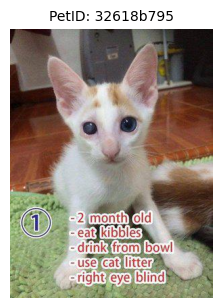


PetID: f5d7daf1a
AdoptionSpeed: 3
Description: benjy was found crying at the side of an eroded monsoon drain when he was around 10days old.his mum and others were poisoned behind the bush near the drain.his family members were all short legged.i h...


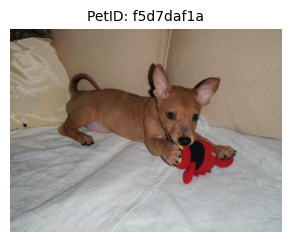


PetID: 170fa3d49
AdoptionSpeed: 3
Description: rescue dog, comes with tick fever and skin problem, under treatment, female estimate 5 years old, not spayed. not toilet train yet. wanted someone to really care of her, give her lot of attention, and...


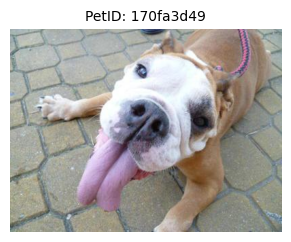


PetID: f98750599
AdoptionSpeed: 2
Description: a real cute girl up for adoption. she was rescued in front of iskl. she was playing with her brothers and sisters. please open your hearts out to her. please call immediately. a must view.


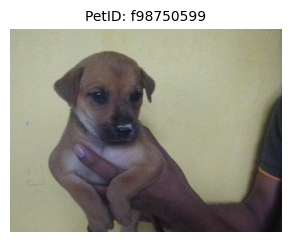


PetID: 8cf93cab0
AdoptionSpeed: 4
Description: found him on the street. very cute but i am unable to keep him. about as big as my hand, and loves to explore.


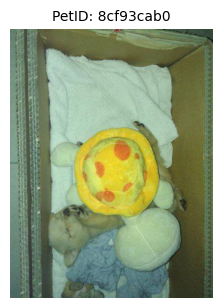

In [29]:
def show_random_examples(df, img_dir, n=5):
    """Display n random examples with image, description, adoption speed, and sentiment."""
    sample = df.sample(n)
    for idx, row in sample.iterrows():
        pet_id = row["PetID"]
        description = row["Description"]
        adoption_speed = row["AdoptionSpeed"] if "AdoptionSpeed" in row else "N/A"
        img_files = list(img_dir.glob(f"{pet_id}*.jpg"))
        print(f"\nPetID: {pet_id}")
        print(f"AdoptionSpeed: {adoption_speed}")
        print(
            f"Description: {description[:200]}{'...' if len(description) > 200 else ''}"
        )
        if img_files:
            img = Image.open(img_files[0]).convert("RGB")
            plt.figure(figsize=(3.5, 3.5))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"PetID: {pet_id}", fontsize=10)
            plt.show()
        else:
            print("No image found.")


show_random_examples(train_df, IMG_TRAIN_DIR, n=5)

### Class balance

Class counts:
 AdoptionSpeed
1    1196
2    1771
3    1327
4    2132
Name: count, dtype: int64
Class distribution (%):
 AdoptionSpeed
1    18.61
2    27.56
3    20.65
4    33.18
Name: count, dtype: float64


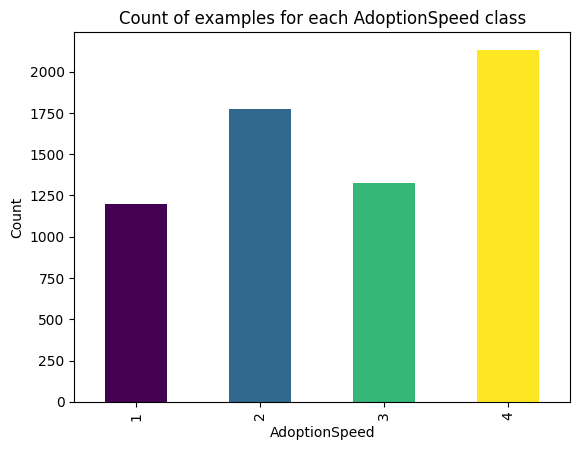

In [30]:
def plot_class_balance(df):
    """Plot the class balance of the AdoptionSpeed column."""
    counts = df["AdoptionSpeed"].value_counts().sort_index()
    print("Class counts:\n", counts)
    print("Class distribution (%):\n", (100 * counts / counts.sum()).round(2))
    counts.plot(kind="bar", color=plt.cm.viridis(np.linspace(0, 1, counts.size)))
    plt.xlabel("AdoptionSpeed")
    plt.ylabel("Count")
    plt.title("Count of examples for each AdoptionSpeed class")
    plt.show()


plot_class_balance(train_df)

## BERT Embeddings (Descriptions)

In [31]:
def get_bert_embeddings(
    texts, batch_size=64, model_name="sentence-transformers/paraphrase-MiniLM-L6-v2"
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="BERT embedding"):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(
            batch.tolist(), padding=True, truncation=True, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            output = model(**inputs)
            emb = output.last_hidden_state.mean(dim=1).cpu().numpy()
        embs.append(emb)
    return np.vstack(embs)


if not (OUTPUTS / "desc_bert_train.npy").exists():
    bert_train = get_bert_embeddings(train_df["Description"])
    np.save(OUTPUTS / "desc_bert_train.npy", bert_train)
if not (OUTPUTS / "desc_bert_test.npy").exists():
    bert_test = get_bert_embeddings(test_df["Description"])
    np.save(OUTPUTS / "desc_bert_test.npy", bert_test)

BERT embedding: 100%|██████████| 30/30 [00:01<00:00, 22.90it/s]


## CLIP Embeddings (Images, first image of each PetID)

In [32]:
def get_clip_embeddings(img_dir, df, split="train"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    feats = []
    for pet_id in tqdm(df["PetID"], desc=f"CLIP {split}"):
        img_files = list(img_dir.glob(f"{pet_id}*.jpg"))
        if not img_files:
            feats.append(np.zeros(512, dtype=np.float32))
            continue
        image = Image.open(img_files[0]).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            feat = model.get_image_features(**inputs)
        feats.append(feat.cpu().numpy().flatten())
    feats = np.stack(feats)
    np.save(OUTPUTS / f"clip_{split}.npy", feats)
    print(f"CLIP {split} shape:", feats.shape)


if not (OUTPUTS / "clip_train.npy").exists():
    get_clip_embeddings(IMG_TRAIN_DIR, train_df, "train")
if not (OUTPUTS / "clip_test.npy").exists():
    get_clip_embeddings(IMG_TEST_DIR, test_df, "test")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
CLIP train: 100%|██████████| 6426/6426 [01:11<00:00, 89.75it/s]


CLIP train shape: (6426, 512)


CLIP test: 100%|██████████| 1886/1886 [00:12<00:00, 155.80it/s]

CLIP test shape: (1886, 512)


## Feature Engineering (Mean/Cat Encoding + Tabular + Embeddings)

In [33]:
display(train_df.head(2))

,PetID,Description,AdoptionSpeed,has_image,Description_no_stopwords,Description_stopword_count,Description_stopword_ratio,desc_length,desc_word_count,desc_unique_words,desc_words_vs_unique,desc_capitals,desc_caps_vs_length,desc_num_exclamation_marks,desc_num_question_marks,desc_num_punctuation,desc_num_symbols,desc_num_smilies,desc_num_sad
0,d3b4f29f8,mayleen and flo are two lovely adorable sister...,2,True,mayleen flo two lovely adorable sisters. frien...,26,0.419355,355,62,48,0.774193,0,0.0,0,0,9,0,0,0
1,e9dc82251,a total of 5 beautiful tabbys available for ad...,2,True,total 5 beautiful tabbys available adoption. o...,23,0.425926,304,54,46,0.851852,0,0.0,0,0,7,0,0,0


In [34]:
cat_features = []
for col in cat_features:
    le = LabelEncoder()
    vals = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(vals.fillna("NA").astype(str))
    train_df[col + "_le"] = le.transform(train_df[col].fillna("NA").astype(str))
    test_df[col + "_le"] = le.transform(test_df[col].fillna("NA").astype(str))


tab_features = [
    "desc_length",
    "desc_word_count",
    "desc_unique_words",
    "desc_words_vs_unique",
    "desc_capitals",
    "desc_caps_vs_length",
    "desc_num_exclamation_marks",
    "desc_num_question_marks",
    "desc_num_punctuation",
    "desc_num_symbols",
    "desc_num_smilies",
    "desc_num_sad",
    "Description_stopword_count",
    "Description_stopword_ratio",
]

tab_features += [c + "_le" for c in cat_features]
display(tab_features)

bert_train = np.load(OUTPUTS / "desc_bert_train.npy")
bert_test = np.load(OUTPUTS / "desc_bert_test.npy")
clip_train = np.load(OUTPUTS / "clip_train.npy")
clip_test = np.load(OUTPUTS / "clip_test.npy")

X_tab = np.hstack([train_df[tab_features].values, bert_train, clip_train])
X_test_tab = np.hstack([test_df[tab_features].values, bert_test, clip_test])
y = train_df["AdoptionSpeed"].values


sample_weight = compute_sample_weight(class_weight="balanced", y=y)

['desc_length',
 'desc_word_count',
 'desc_unique_words',
 'desc_words_vs_unique',
 'desc_capitals',
 'desc_caps_vs_length',
 'desc_num_exclamation_marks',
 'desc_num_question_marks',
 'desc_num_punctuation',
 'desc_num_symbols',
 'desc_num_smilies',
 'desc_num_sad',
 'Description_stopword_count',
 'Description_stopword_ratio']

## Optuna Hyperparameter Tuning (LightGBM)

In [35]:
def objective_lgbm(trial):
    """Objective function for LightGBM hyperparameter optimization."""
    params = {
        "objective": "regression",
        "metric": "rmse",
        "n_estimators": 400,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 24, 128),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True),
        "random_state": 42,
        "verbosity": -1,
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    preds = np.zeros_like(y, dtype=float)
    for tr_idx, val_idx in cv.split(X_tab, y):
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tab[tr_idx], y[tr_idx], sample_weight=sample_weight[tr_idx])
        preds[val_idx] = model.predict(X_tab[val_idx])
    round_preds = np.clip(np.round(preds), 0, 4).astype(int)
    return -quadratic_weighted_kappa(y, round_preds)


study = optuna.create_study()
study.optimize(objective_lgbm, n_trials=15)
best_params = study.best_params
print("Best LightGBM params:", best_params)

[I 2025-05-27 13:33:25,732] A new study created in memory with name: no-name-97d2eadd-b9d8-4cac-bacc-10e4a99b7833
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-05-27 13:33:55,076] Trial 0 finished with value: -0.4139686807869314 and parameters: {'learning_rate': 0.09745

Best LightGBM params: {'learning_rate': 0.045635546532698364, 'num_leaves': 38, 'min_child_samples': 27, 'subsample': 0.9584487473136005, 'colsample_bytree': 0.7896854059948339, 'reg_alpha': 0.0076645356765192825, 'reg_lambda': 0.20114969765939736}


## Training Models + Blending (LGBM, CatBoost, XGBoost)

/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature

OOF QWK (blended): 0.7655782034106445


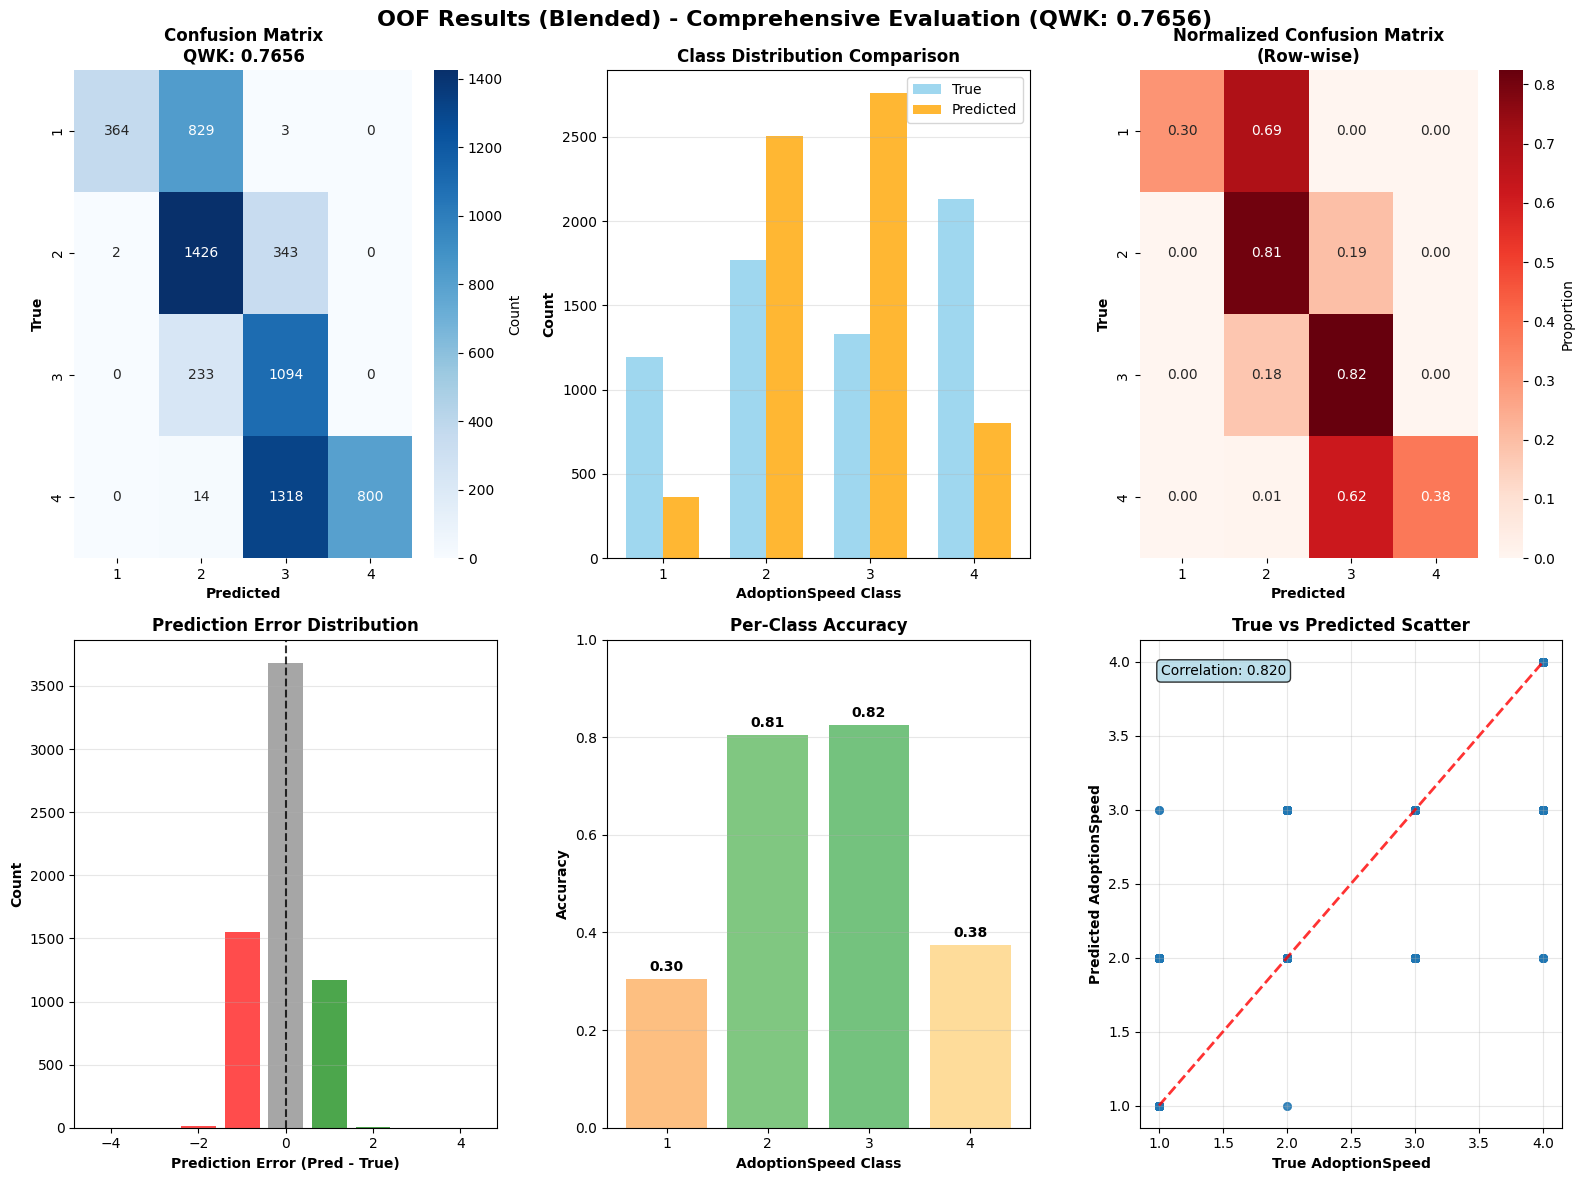

{'qwk': 0.7655782034106445,
 'confusion_matrix': array([[ 364,  829,    3,    0],
        [   2, 1426,  343,    0],
        [   0,  233, 1094,    0],
        [   0,   14, 1318,  800]]),
 'class_accuracies': [0.30434782608695654,
  0.8051948051948052,
  0.8244159758854559,
  0.37523452157598497],
 'correlation': 0.8201096255760228}

In [36]:
def train_and_evaluate(X, y, X_test, sample_weight, best_params):
    """Train and evaluate LightGBM model with cross-validation."""
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(X))
    preds_test = np.zeros((len(X_test), folds.n_splits))
    for i, (tr_idx, val_idx) in enumerate(folds.split(X, y)):
        model = lgb.LGBMRegressor(**best_params)
        model.fit(X[tr_idx], y[tr_idx], sample_weight=sample_weight[tr_idx])
        oof[val_idx] = model.predict(X[val_idx])
        preds_test[:, i] = model.predict(X_test)
    return oof, preds_test.mean(axis=1)


def train_catboost(X, y, X_test, sample_weight):
    """Train CatBoost model and return OOF and test predictions."""
    model = CatBoostRegressor(
        iterations=400,
        learning_rate=0.04,
        depth=7,
        random_seed=42,
        verbose=0,
        loss_function="RMSE",
    )
    model.fit(X, y, sample_weight=sample_weight)
    return model.predict(X), model.predict(X_test)


def train_xgboost(X, y, X_test, sample_weight):
    """Train XGBoost model and return OOF and test predictions."""
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=400,
        learning_rate=0.04,
        max_depth=7,
        random_state=42,
    )
    model.fit(X, y, sample_weight=sample_weight)
    return model.predict(X), model.predict(X_test)


oof_lgb, pred_lgb = train_and_evaluate(X_tab, y, X_test_tab, sample_weight, best_params)
oof_cat, pred_cat = train_catboost(X_tab, y, X_test_tab, sample_weight)
oof_xgb, pred_xgb = train_xgboost(X_tab, y, X_test_tab, sample_weight)

# Simple average stack
blended = (oof_lgb + oof_cat + oof_xgb) / 3
pred_blended = (pred_lgb + pred_cat + pred_xgb) / 3
round_preds = np.clip(np.round(blended), 0, 4).astype(int)
print("OOF QWK (blended):", quadratic_weighted_kappa(y, round_preds))
plot_detailed_results(y, round_preds, "OOF Results (Blended)")

## Final train and submission

In [37]:
class OptimizedRounder:
    """Find optimal rounding thresholds for regression → classes."""

    def __init__(self):
        self.coef_ = [0.5, 1.5, 2.5, 3.5]

    def _kappa_loss(self, coef, X, y):
        X_p = self.predict(X, coef)
        return -quadratic_weighted_kappa(y, X_p)

    def fit(self, X, y):
        from scipy.optimize import minimize

        loss_partial = lambda c: self._kappa_loss(c, X, y)
        initial_coef = self.coef_
        bounds = [(None, None)] * len(initial_coef)
        result = minimize(loss_partial, initial_coef, method="nelder-mead")
        self.coef_ = result.x

    def predict(self, X, coef=None):
        if coef is None:
            coef = self.coef_
        coef = np.sort(coef)
        X_p = np.digitize(X, coef)
        return X_p

    def coefficients(self):
        return self.coef_

In [38]:
def create_enhanced_weights(y, minority_classes=[3, 4], minority_factor=3.0):
    """Create weights with additional enhancement for minority classes"""

    balanced_weights = compute_sample_weight(class_weight="balanced", y=y)
    is_minority = np.isin(y, minority_classes)

    enhanced_weights = balanced_weights.copy()
    enhanced_weights[is_minority] *= minority_factor

    print(f"Mean weights for all classes: {balanced_weights.mean():.4f}")
    print(f"Mean weight for minority classes: {balanced_weights[is_minority].mean():.4f}")
    print(f"Mean weight for minority classes (after enhancement): {enhanced_weights[is_minority].mean():.4f}")

    return enhanced_weights

In [ ]:
def apply_smote_oversampling(X, y, sampling_strategy=None, random_state=42):
    """Apply SMOTE for oversampling minority classes"""

    if sampling_strategy is None:
        class_counts = np.bincount(y)
        max_count = class_counts.max()

        target_count = max_count // 2
        sampling_strategy = {}
        for cls, count in enumerate(class_counts):
            # Only add class to strategy if it exists (count > 0) and has fewer samples than max
            if count > 0 and count < max_count:
                sampling_strategy[cls] = min(max_count, max(target_count, count))

    # Verify that all classes in sampling_strategy exist in the data
    # This prevents the "target class is not present in the data" error
    present_classes = set(np.unique(y))
    sampling_strategy = {cls: count for cls, count in sampling_strategy.items() 
                        if cls in present_classes}

    class_counts_before = np.bincount(y)
    print("Distribution of classes before SMOTE:")
    for cls, count in enumerate(class_counts_before):
        print(f"Class {cls}: {count} samples ({100*count/len(y):.2f}%)")

    smote = SMOTE(sampling_strategy=sampling_strategy, random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    class_counts_after = np.bincount(y_resampled)
    print("\nDistribution of classes after SMOTE:")
    for cls, count in enumerate(class_counts_after):
        print(f"Class {cls}: {count} samples ({100*count/len(y_resampled):.2f}%)")

    plt.figure(figsize=(10, 6))
    plt.bar(
        np.arange(len(class_counts_before)) - 0.2,
        class_counts_before,
        width=0.4,
        color="skyblue",
        label="Before SMOTE",
    )
    plt.bar(
        np.arange(len(class_counts_after)) + 0.2,
        class_counts_after,
        width=0.4,
        color="salmon",
        label="After SMOTE",
    )
    plt.xlabel("Class (AdoptionSpeed)", fontsize=12)
    plt.ylabel("Number of samples", fontsize=12)
    plt.title("Comparison of class distribution before and after SMOTE", fontsize=14)
    plt.xticks(np.arange(len(class_counts_before)), np.arange(len(class_counts_before)))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return X_resampled, y_resampled

Using enhanced weights for final model...
Mean weights for all classes: 1.0000
Mean weight for minority classes: 0.9289
Mean weight for minority classes (after enhancement): 4.6444
Train final model LightGBM...


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Train final model CatBoost...
Train final model XGBoost...


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


FINAL QWK (train, blended): 0.8060


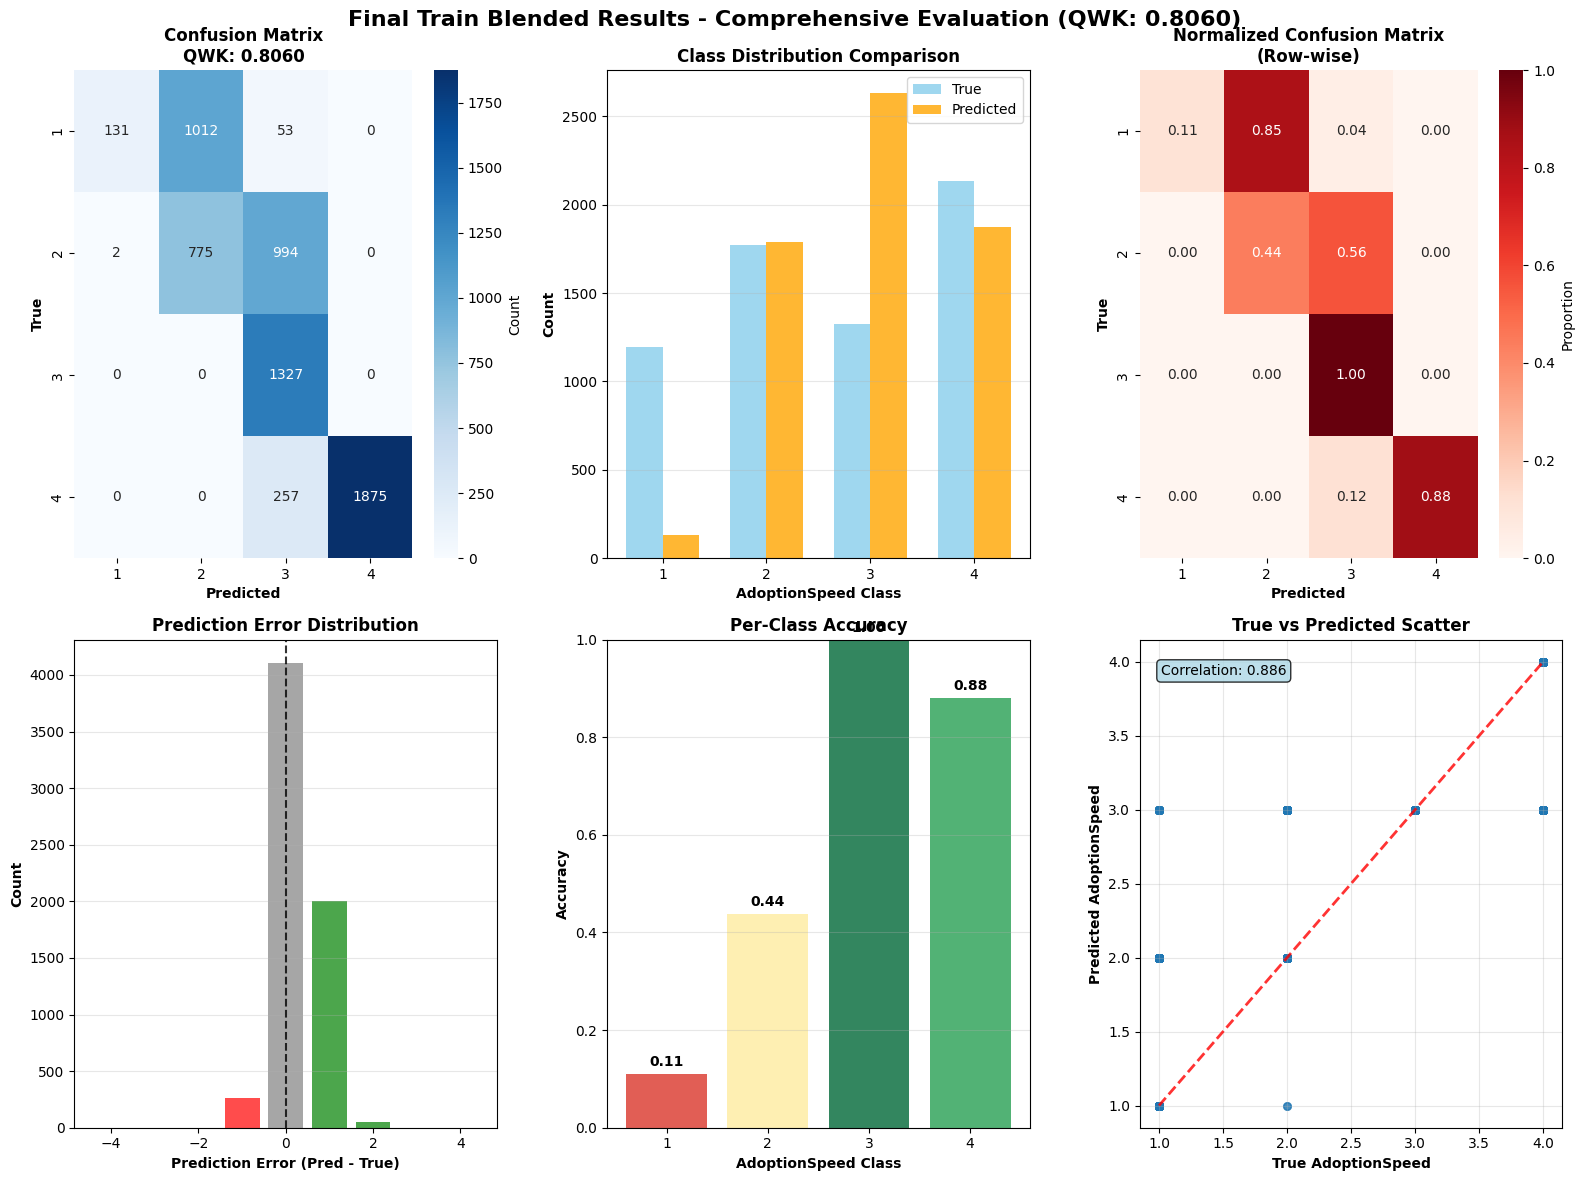

FINAL submission saved!


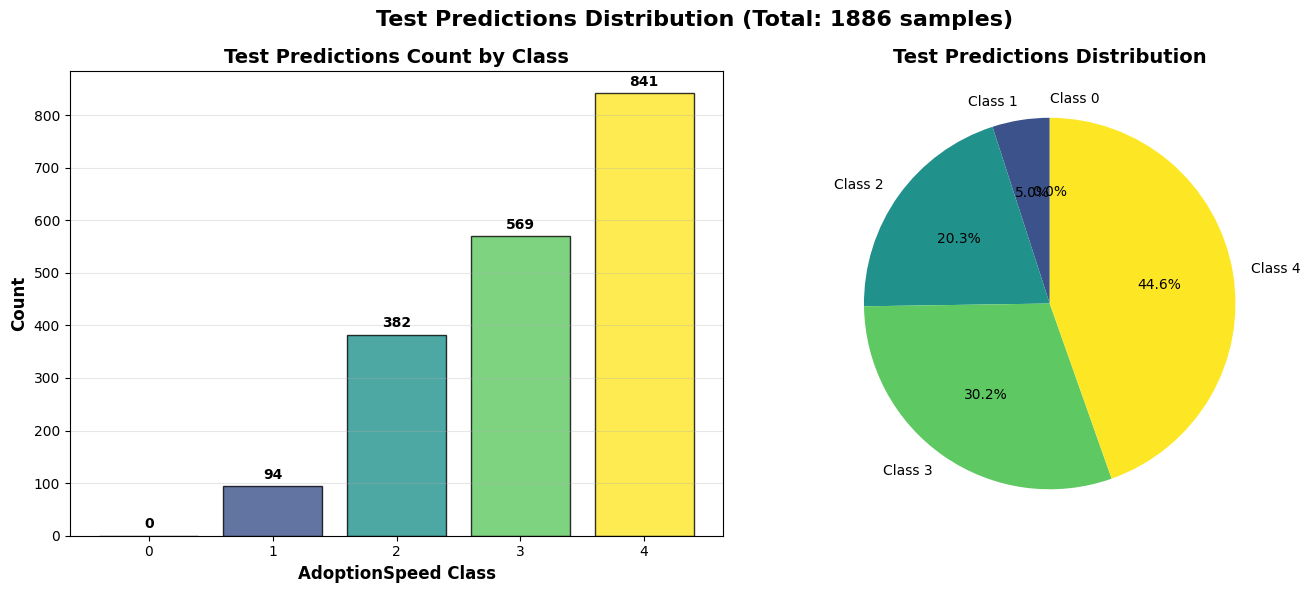


=== Test Predictions Distribution Summary ===
Total samples: 1886
Class 0:    0 (  0.0%)
Class 1:   94 (  5.0%)
Class 2:  382 ( 20.3%)
Class 3:  569 ( 30.2%)
Class 4:  841 ( 44.6%)


In [40]:
# True for enhanced weights, False for standard weights
use_enhanced_weights = True
use_smote = False
class_counts = np.bincount(y)

if use_smote:
    print("Using SMOTE for oversampling...")
    X_final_train, y_final_train = apply_smote_oversampling(
        X_tab, y, 
        sampling_strategy={
            cls: max(count, class_counts.max() // 2) 
            for cls, count in enumerate(class_counts)
            if count < class_counts.max()
        }
    )
else:
    X_final_train, y_final_train = X_tab, y

# Prepare final weights
if use_enhanced_weights:
    print("Using enhanced weights for final model...")
    final_weights = create_enhanced_weights(y_final_train, minority_classes=[3, 4], minority_factor=5.0)
else:
    if use_smote:
        final_weights = np.ones(len(y_final_train))
    else:
        final_weights = sample_weight


print("Train final model LightGBM...")
lgb_final = lgb.LGBMRegressor(**best_params)
lgb_final.fit(X_final_train, y_final_train, sample_weight=final_weights)
lgb_pred_test = lgb_final.predict(X_test_tab)

print("Train final model CatBoost...")
cat_final = CatBoostRegressor(
    iterations=400,
    learning_rate=0.04,
    depth=7,
    random_seed=42,
    verbose=0,
    loss_function="RMSE",
)
cat_final.fit(X_final_train, y_final_train, sample_weight=final_weights)
cat_pred_test = cat_final.predict(X_test_tab)

print("Train final model XGBoost...")
xgb_final = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    learning_rate=0.04,
    max_depth=7,
    random_state=42,
)
xgb_final.fit(X_final_train, y_final_train, sample_weight=final_weights)
xgb_pred_test = xgb_final.predict(X_test_tab)

lgb_pred_train = lgb_final.predict(X_tab)
cat_pred_train = cat_final.predict(X_tab)
xgb_pred_train = xgb_final.predict(X_tab)
pred_blended_train = (lgb_pred_train + cat_pred_train + xgb_pred_train) / 3
round_blended_train = np.clip(np.round(pred_blended_train), 0, 4).astype(int)
qwk_final = quadratic_weighted_kappa(y, round_blended_train)
print(f"FINAL QWK (train, blended): {qwk_final:.4f}")
plot_detailed_results(y, round_blended_train, "Final Train Blended Results")

optR = OptimizedRounder()
optR.fit(blended, y)  # blended = (oof_lgb + oof_cat + oof_xgb) / 3
best_coef = optR.coefficients()

pred_blended_final = (lgb_pred_test + cat_pred_test + xgb_pred_test) / 3
final_preds = optR.predict(pred_blended_final, best_coef)
final_preds = np.clip(final_preds, 0, 4).astype(int)

submission = pd.DataFrame(
    {
        # "PetID": test_df["PetID"][:1891],
        # "AdoptionSpeed": final_preds[:1891],
        "PetID": test_df["PetID"],
        "AdoptionSpeed": final_preds,
    }
)

submission.to_csv(OUTPUTS / "submission.csv", index=False)
print("FINAL submission saved!")
plot_test_predictions_distribution(submission["AdoptionSpeed"].values)

Minority Class Report:
3    2412
4     800
2     247
Name: count, dtype: int64


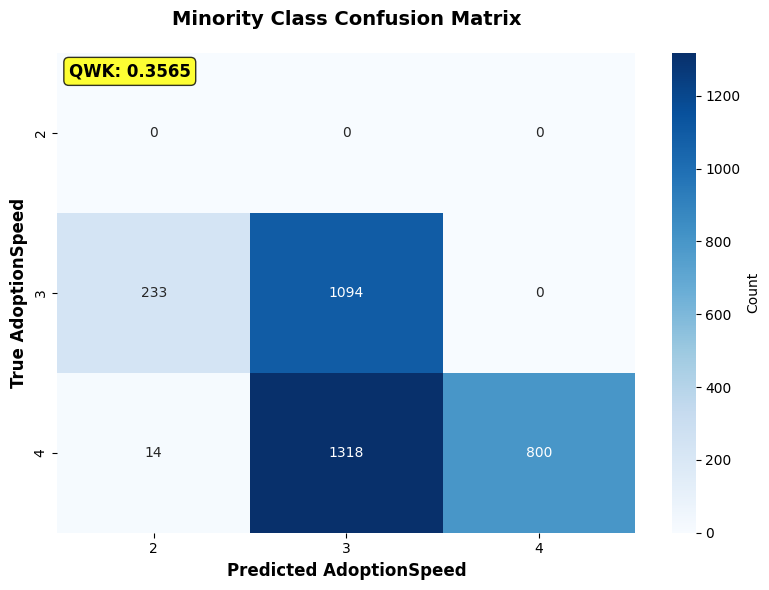

In [43]:
def analyze_minority_class(y_true, y_pred, minority_classes=[3, 4]):
    """Analyze and visualize results for minority classes."""
    mask = np.isin(y_true, minority_classes)
    print("Minority Class Report:")
    print(pd.Series(y_pred[mask]).value_counts())
    plot_confusion_matrix(
        y_true[mask], y_pred[mask], title="Minority Class Confusion Matrix"
    )


analyze_minority_class(y, round_preds)

## Impruve handling of minority classes

Mean weights for all classes: 1.0000
Mean weight for minority classes: 0.9289
Mean weight for minority classes (after enhancement): 4.6444
Sampling strategy: {1: 1196, 2: 1771, 3: 1327}
Distribution of classes before SMOTE:
Class 0: 0 samples (0.00%)
Class 1: 1196 samples (18.61%)
Class 2: 1771 samples (27.56%)
Class 3: 1327 samples (20.65%)
Class 4: 2132 samples (33.18%)

Distribution of classes after SMOTE:
Class 0: 0 samples (0.00%)
Class 1: 1196 samples (18.61%)
Class 2: 1771 samples (27.56%)
Class 3: 1327 samples (20.65%)
Class 4: 2132 samples (33.18%)


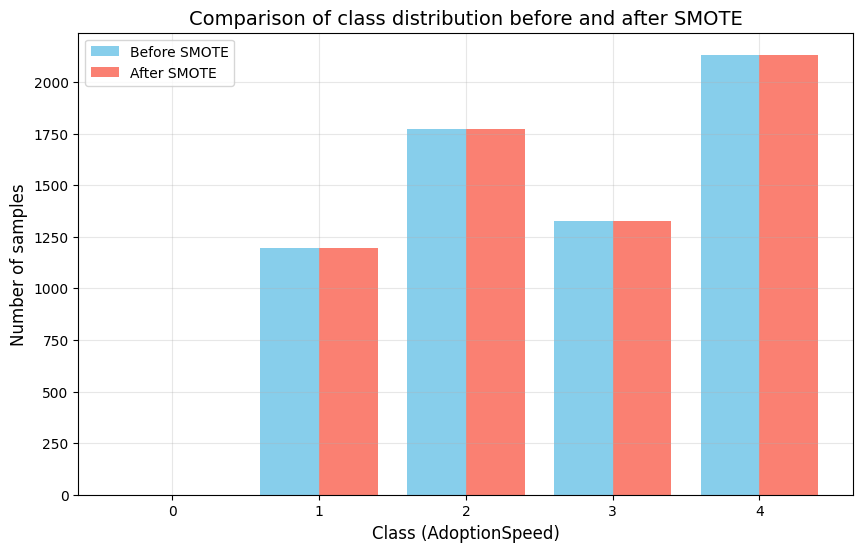


=== Train models with enhanced weights (without SMOTE) ===
QWK with enhanced weights: 0.6794
Minority Class Report:
3    1931
4    1527
2       1
Name: count, dtype: int64
QWK with enhanced weights: 0.6794
Minority Class Report:
3    1931
4    1527
2       1
Name: count, dtype: int64


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


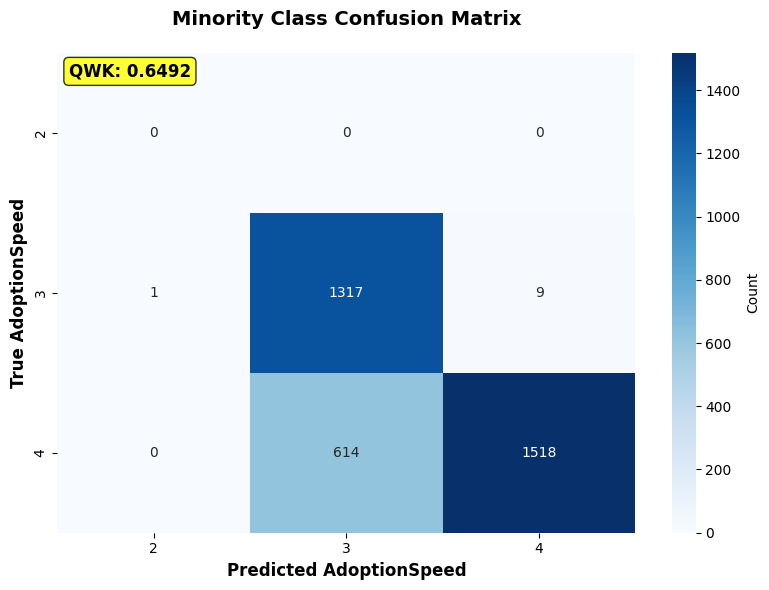


=== Train models on data with SMOTE ===
QWK with SMOTE: 0.7316
Minority Class Report:
3    2244
4     934
2     281
Name: count, dtype: int64
QWK with SMOTE: 0.7316
Minority Class Report:
3    2244
4     934
2     281
Name: count, dtype: int64


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


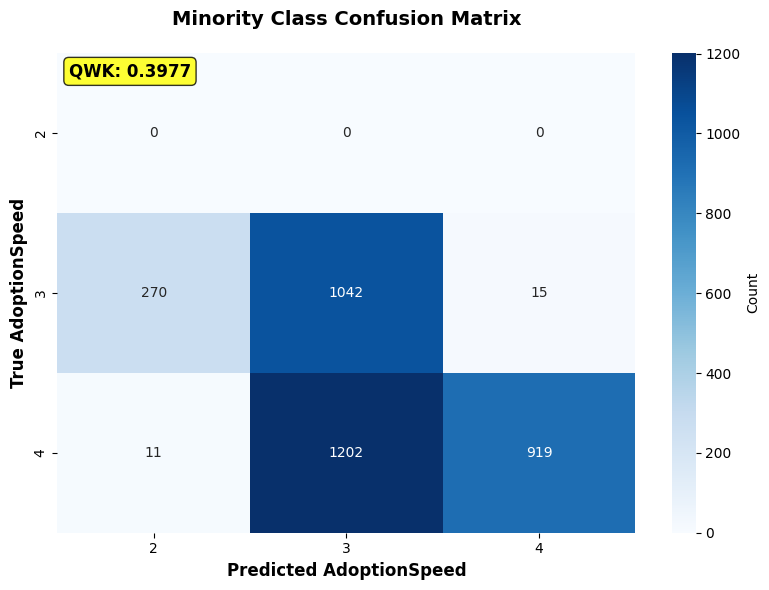


=== Train models on data with SMOTE and enhanced weights ===
Mean weights for all classes: 1.0000
Mean weight for minority classes: 0.9289
Mean weight for minority classes (after enhancement): 1.8578
QWK with SMOTE and enhanced weights: 0.7127
Minority Class Report:
3    2447
4     929
2      83
Name: count, dtype: int64
QWK with SMOTE and enhanced weights: 0.7127
Minority Class Report:
3    2447
4     929
2      83
Name: count, dtype: int64


/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


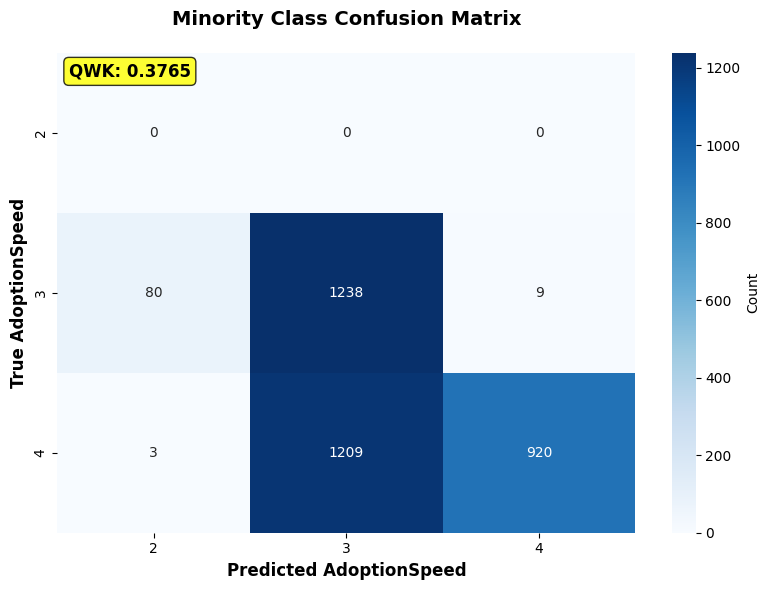


=== Comparison table of QWK for minority classes ===
                     Method  QWK (overall)  QWK (мінорітарні класи)
0                Base model       0.765578                 0.356506
1          Enhanced weights       0.679437                 0.649213
2                     SMOTE       0.731584                 0.397725
3  SMOTE + enhanced weights       0.712672                 0.376521

Best method for minority classes: Enhanced weights


In [ ]:
# Create enhanced weights for minority classes
enhanced_weights = create_enhanced_weights(y, minority_classes=[3, 4], minority_factor=5.0)

# Apply SMOTE to create synthetic examples
# Define the oversampling strategy - increase the underrepresented classes
class_counts = np.bincount(y)
max_count = class_counts.max() // 2  # Target count - half of the maximum class

sampling_strategy = {}
for cls, count in enumerate(class_counts):
    # Only add class to strategy if it exists (count > 0) and has fewer samples than the maximum class
    if count > 0 and count < class_counts.max():
        sampling_strategy[cls] = max(count, max_count)

print("Sampling strategy:", sampling_strategy)

# Apply SMOTE only to the training data, not to the test data
X_smote, y_smote = apply_smote_oversampling(X_tab, y, sampling_strategy=sampling_strategy)

# Train models with enhanced weights (without SMOTE)
print("\n=== Train models with enhanced weights (without SMOTE) ===")
lgb_enhanced = lgb.LGBMRegressor(**best_params)
lgb_enhanced.fit(X_tab, y, sample_weight=enhanced_weights)
lgb_pred_enhanced = lgb_enhanced.predict(X_tab)
round_preds_enhanced = np.clip(np.round(lgb_pred_enhanced), 0, 4).astype(int)
qwk_enhanced = quadratic_weighted_kappa(y, round_preds_enhanced)
print(f"QWK with enhanced weights: {qwk_enhanced:.4f}")
analyze_minority_class(y, round_preds_enhanced)

# Train models on data with SMOTE
print("\n=== Train models on data with SMOTE ===")
lgb_smote = lgb.LGBMRegressor(**best_params)
lgb_smote.fit(X_smote, y_smote)  # No additional weights needed here since SMOTE has balanced the classes
lgb_pred_smote = lgb_smote.predict(X_tab)
round_preds_smote = np.clip(np.round(lgb_pred_smote), 0, 4).astype(int)
qwk_smote = quadratic_weighted_kappa(y, round_preds_smote)
print(f"QWK with SMOTE: {qwk_smote:.4f}")
analyze_minority_class(y, round_preds_smote)

# Train models on data with SMOTE and enhanced weights
print("\n=== Train models on data with SMOTE and enhanced weights ===")
# Compute new weights for SMOTE data
smote_weights = create_enhanced_weights(y_smote, minority_classes=[3, 4], minority_factor=2.0)
lgb_combined = lgb.LGBMRegressor(**best_params)
lgb_combined.fit(X_smote, y_smote, sample_weight=smote_weights)
lgb_pred_combined = lgb_combined.predict(X_tab)
round_preds_combined = np.clip(np.round(lgb_pred_combined), 0, 4).astype(int)
qwk_combined = quadratic_weighted_kappa(y, round_preds_combined)
print(f"QWK with SMOTE and enhanced weights: {qwk_combined:.4f}")
analyze_minority_class(y, round_preds_combined)

# Comparison of results for minority classes
minority_mask = np.isin(y, [3, 4])
print("\n=== Comparison table of QWK for minority classes ===")
methods = ["Base model", "Enhanced weights", "SMOTE", "SMOTE + enhanced weights"]
qwks = [
    quadratic_weighted_kappa(y[minority_mask], round_preds[minority_mask]),
    quadratic_weighted_kappa(y[minority_mask], round_preds_enhanced[minority_mask]),
    quadratic_weighted_kappa(y[minority_mask], round_preds_smote[minority_mask]),
    quadratic_weighted_kappa(y[minority_mask], round_preds_combined[minority_mask])
]

comparison_df = pd.DataFrame(
    {
        "Method": methods,
        "QWK (overall)": [
            quadratic_weighted_kappa(y, round_preds),
            qwk_enhanced,
            qwk_smote,
            qwk_combined,
        ],
        "QWK (Minority Class)": qwks,
    }
)
print(comparison_df)

# Determine the best method for further fine-tuning the final model
best_method_idx = np.argmax(qwks)
best_method = methods[best_method_idx]
print(f"\nBest method for minority classes: {best_method}")